## Banking Customer Dataset - EDA Just going through the usual EDA steps here - check data quality first, then look at individual columns, then start comparing things against each other to see if anything interesting pops up.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os
import warnings

warnings.filterwarnings("ignore")

## Load + Basic cleanup

In [2]:
pip install pandas sqlalchemy pymysql

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# connection to sql database
from sqlalchemy import create_engine

username = 'root'
password = 'Rawatanuj_123'
host = 'localhost'
port = '3306'
database = 'banking_case'

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

In [4]:
engine.connect()

In [5]:
query = "SELECT * FROM banking_case.bancustomer"

In [6]:
df = pd.read_sql(query, engine)

In [7]:
from matplotlib import figure
# just some plot styling so everything looks consistent

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = 'bold'

In [ ]:
# Creating the Output Directory
OUTPUT_DIR = "Clean_bank_dataset"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [9]:
# small helper so I don't have to repeat tight_layout + savefig everywhere
def save_fig(fig,name):
  fig.tight_layout()
  fig.savefig(f"{OUTPUT_DIR}/{name}.png", bbox_inches='tight')
  plt.show()
  plt.close(fig)
  print(f"Saved: {OUTPUT_DIR}/{name}.png")

In [ ]:
# the join date column was stored as text (dd-mm-yyyy), converting to datetime so I can actually do time-based stuff with it later

df['Joined Bank'] = pd.to_datetime(df['Joined Bank'], format='%d-%m-%Y')

In [11]:
print(f'Rows, Column: {df.shape}')

Rows, Column: (3000, 25)


In [12]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


In [13]:
missing = df.isnull().sum()
missing

ï»¿Client ID                0
Name                        0
Age                         0
Location ID                 0
Joined Bank                 0
Banking Contact             0
Nationality                 0
Occupation                  0
Fee Structure               0
Loyalty Classification      0
Estimated Income            0
Superannuation Savings      0
Amount of Credit Cards      0
Credit Card Balance         0
Bank Loans                  0
Bank Deposits               0
Checking Accounts           0
Saving Accounts             0
Foreign Currency Account    0
Business Lending            0
Properties Owned            0
Risk Weighting              0
BRId                        0
GenderId                    0
IAId                        0
dtype: int64

In [14]:
# Quick Stats - Numeric columns:
df.describe()

,Age,Location ID,Joined Bank,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,2010-08-15 00:03:21.600000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
min,17.000000,12.000000,1995-01-03 00:00:00,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,2004-04-01 18:00:00,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,2011-02-18 00:00:00,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,2017-12-24 06:00:00,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,2021-12-31 00:00:00,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000
std,19.854760,12462.273017,NaN,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242


In [15]:
# Quick Stats - Categorical Columns:
df.describe(include='object')

,ï»¿Client ID,Name,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification
count,3000,3000,3000,3000,3000,3000,3000
unique,2940,2913,49,5,195,3,4
top,IND48103,Raymond Mills,Ernest Rivera,European,Structural Analysis Engineer,High,Jade
freq,3,2,77,1309,28,1476,1331


Note: no missing values and no duplicate client IDs, so I didn't need to do

## Univariate - looking at columns one at a time

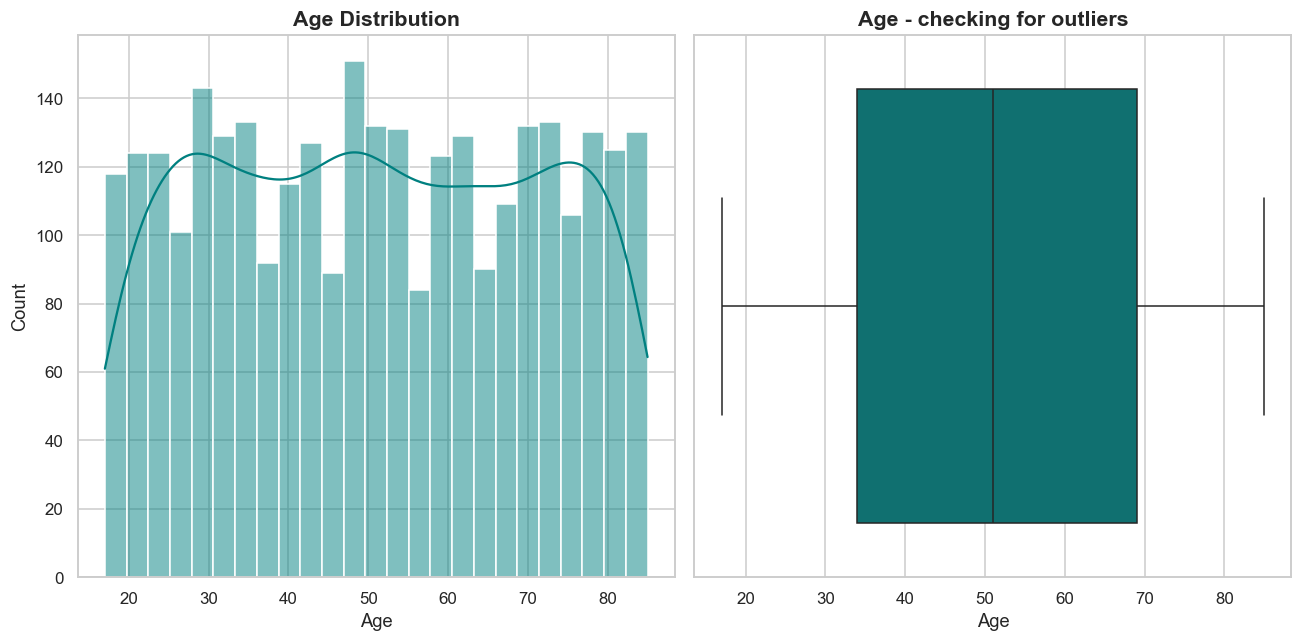

Saved: Clean_bank_dataset/01_age_distribution.png


In [16]:
# age spread
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.histplot(df['Age'], bins= 25, kde=True, color='teal', ax=axes[0])
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

sns.boxplot(x=df['Age'], color='teal',ax=axes[1])
axes[1].set_title("Age - checking for outliers")
save_fig(fig, "01_age_distribution")

Note: age looks fairly spread out with no crazy outliers based on the boxplot. Customer base isn't concentrated in one narrow age band, which is good context for the segmentation stuff later on.

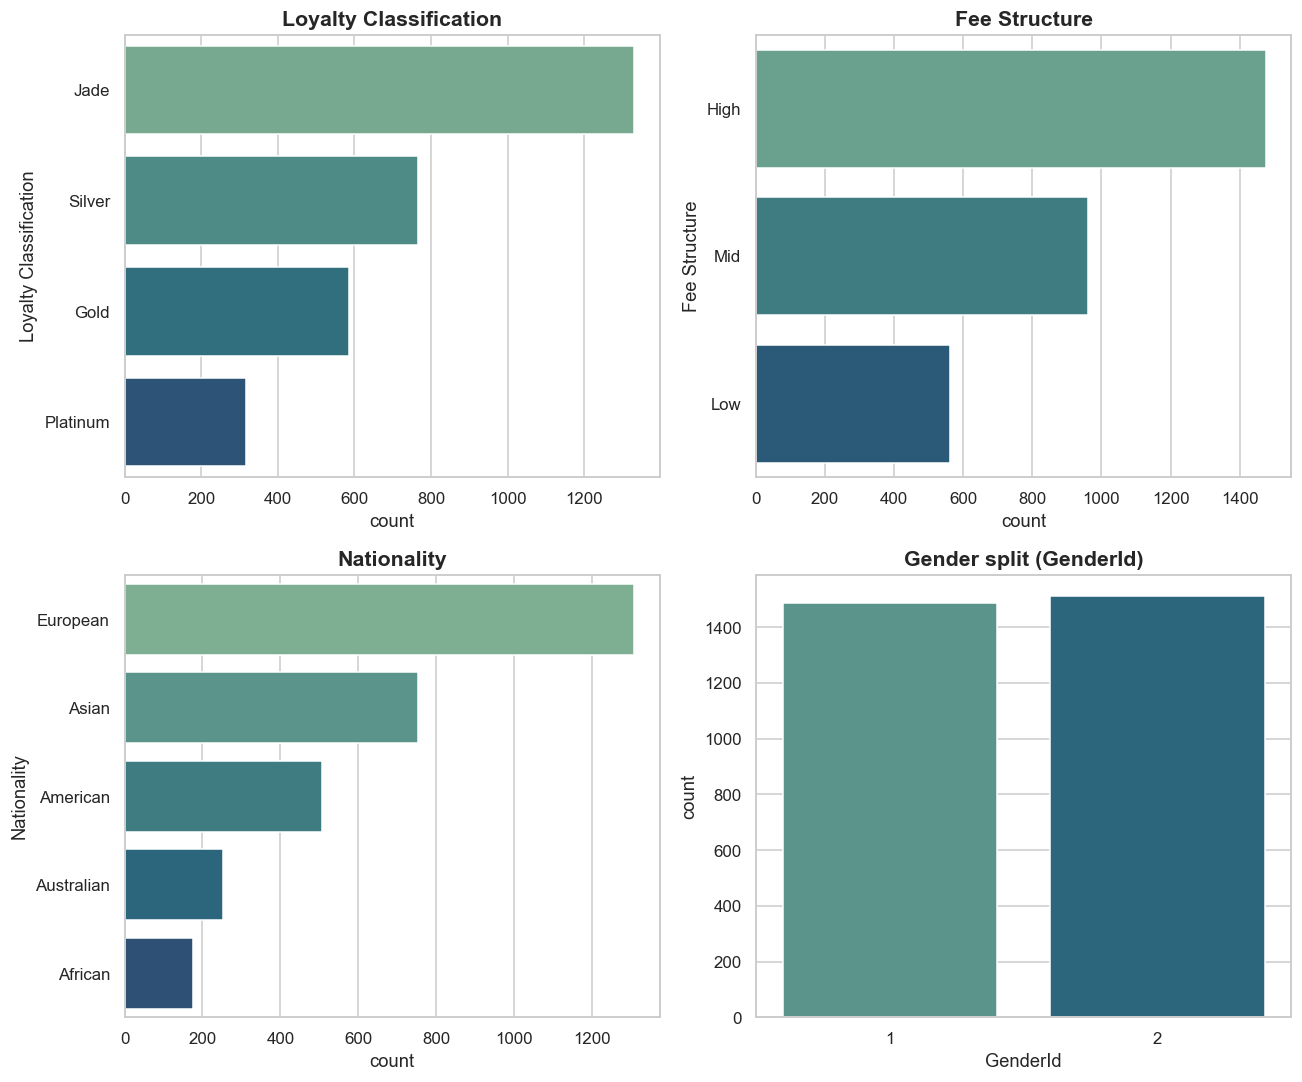

Saved: Clean_bank_dataset/02_categorical_overview.png


In [17]:
# categorical breakdown - loyalty tier, fees structure, nationality, gender
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

order1 = df['Loyalty Classification'].value_counts().index
sns.countplot(data=df, y='Loyalty Classification', order=order1, ax=axes[0, 0], palette='crest')
axes[0, 0].set_title('Loyalty Classification')

order2 = df['Fee Structure'].value_counts().index
sns.countplot(data=df, y='Fee Structure', order=order2, ax=axes[0,1], palette='crest')
axes[0,1].set_title('Fee Structure')

top_nat = df['Nationality'].value_counts().nlargest(10).index
sns.countplot(data=df[df['Nationality'].isin(top_nat)], y='Nationality', order=top_nat, ax=axes[1,0], palette='crest')
axes[1,0].set_title('Nationality')

sns.countplot(data=df, x='GenderId', ax=axes[1,1], palette='crest')
axes[1,1].set_title('Gender split (GenderId)')

save_fig(fig, '02_categorical_overview')

Note: "Jade" is the biggest loyalty tier (about 1,331 of 3,000 customers), and "European" is by far the most common nationality (~1,309 customers) - so the customer base isn't very diverse geographically, it's concentrated in one group. Fee Structure also skews toward "High" (1,476 customers), which is more than the other two tiers put together.

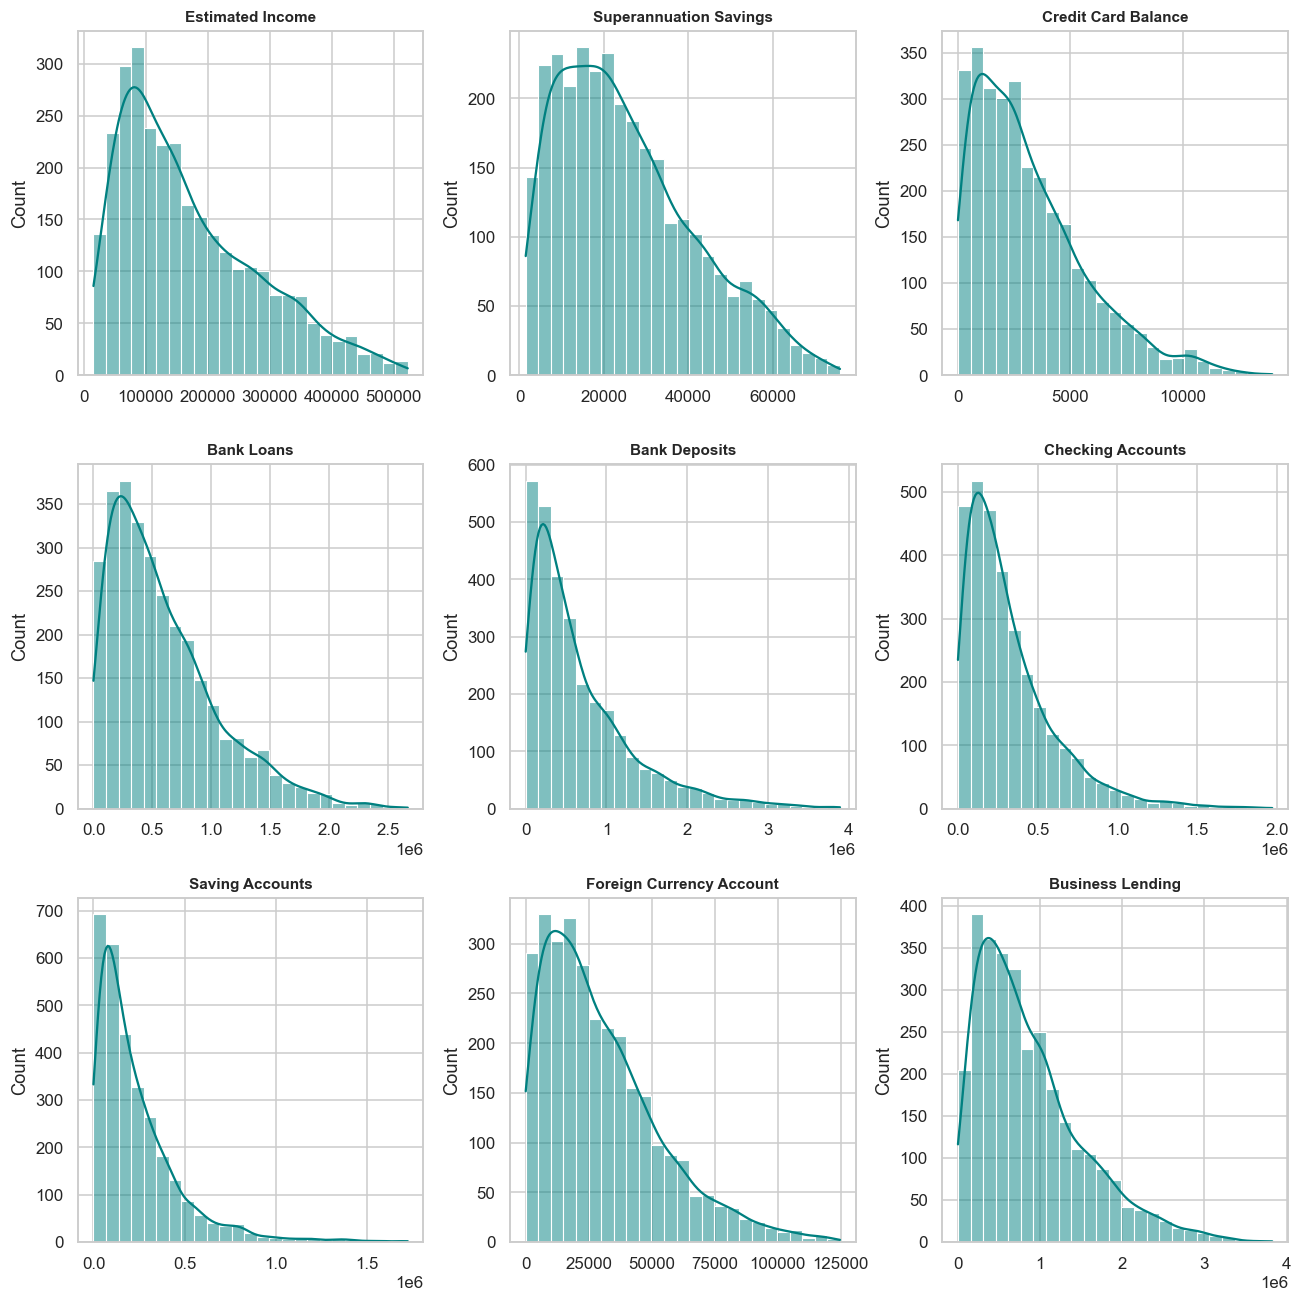

Saved: Clean_bank_dataset/03_financial_distributions.png


In [18]:
# financial columns - checking shape/skew of each one
financial_cols = ["Estimated Income", "Superannuation Savings", "Credit Card Balance", "Bank Loans", "Bank Deposits", "Checking Accounts", "Saving Accounts", "Foreign Currency Account", "Business Lending"]

fig, axes = plt.subplots(3,3, figsize=(12,12))
for ax, col in zip(axes.flatten(), financial_cols):
  sns.histplot(df[col], bins=25, kde=True, color='teal', ax=ax)
  ax.set_title(col, fontsize=10)
  ax.set_xlabel('')

save_fig(fig, "03_financial_distributions")

Note: most of these financial columns are right-skewed (long tail toward high values) which is pretty typical for money-related data - a small number of customers hold way more than the average. This is basically why I run the IQR outlier check further down.

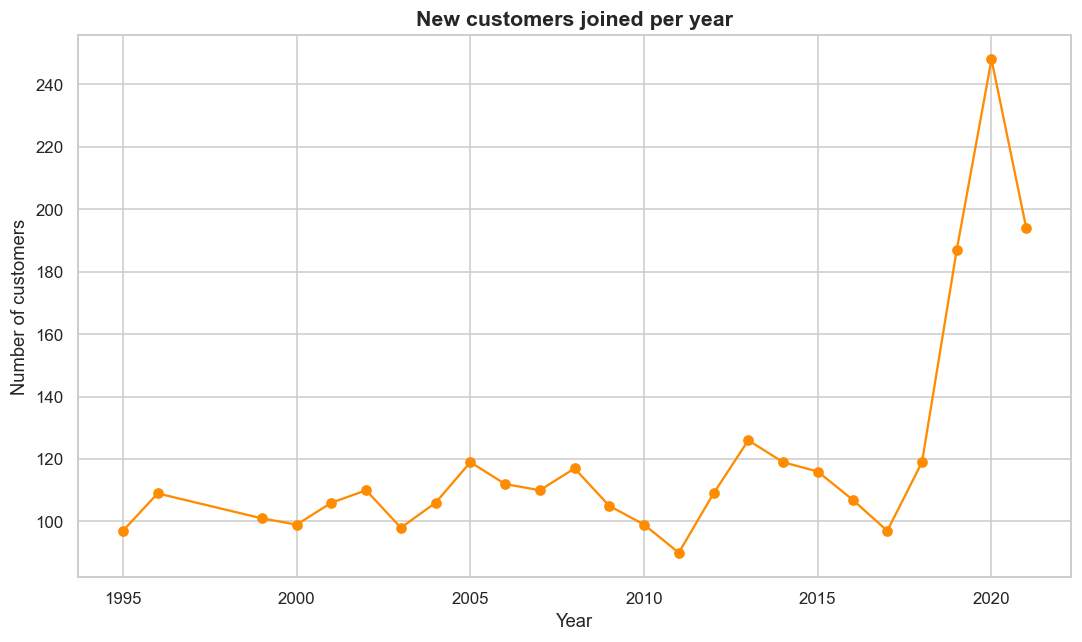

Saved: Clean_bank_dataset/04_new_customers_per_year.png


In [19]:
# how many new customers joined per year
joined_year = df['Joined Bank'].dt.year.value_counts().sort_index()
fix, ax = plt.subplots(figsize=(10, 6))
joined_year.plot(kind='line', marker='o', color='darkorange', ax=ax)
ax.set_title('New customers joined per year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of customers')
save_fig(fix, '04_new_customers_per_year')

Note: look at whether acquisition is trending up, down, or flat over the years - that's a useful one-liner for whoever you present this to.

## Bivariate / Multivariate - comparing columns against each other

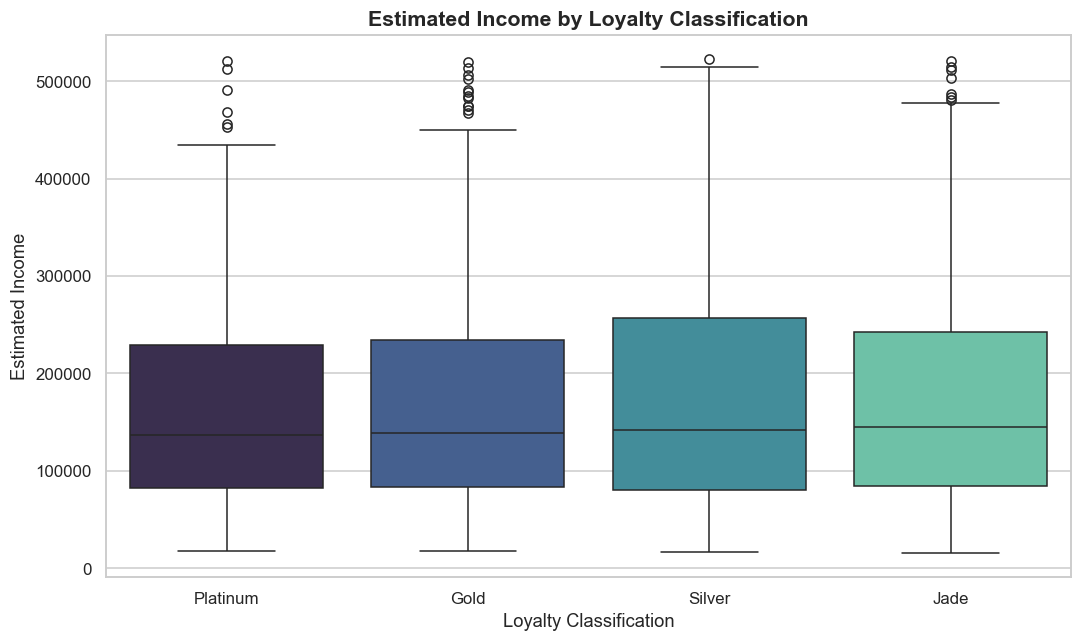

Saved: Clean_bank_dataset/05_income_by_loyalty.png


In [20]:
# does income differ across loyalty tiers?
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(data=df, x='Loyalty Classification', y='Estimated Income', order=df.groupby('Loyalty Classification')['Estimated Income'].median().sort_values().index, palette='mako',ax=ax)
ax.set_title('Estimated Income by Loyalty Classification')
save_fig(fig, '05_income_by_loyalty')


Note: interestingly the median income barely moves across tiers (roughly 137k-145k Platinum to Jade) - so loyalty tier here doesn't look like it's purely income-driven. It's probably based on tenure, product usage, or some other combined score rather than income alone. Worth mentioning this as a finding since it's a little counter-intuitive (you'd expect "Platinum" to mean richest customers, but that's not really what the data shows).

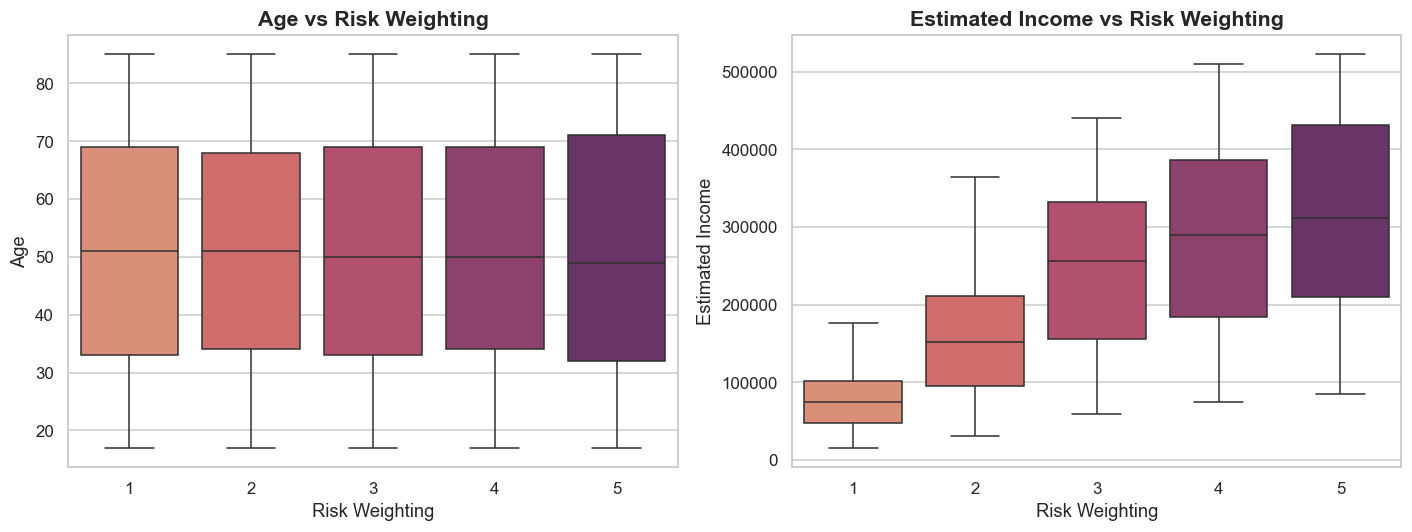

Saved: Clean_bank_dataset/06_risk_weight_analysis.png


In [21]:
# risk weighting vs age and income
fig, axes = plt.subplots(1,2, figsize=(13,5))
sns.boxplot(data=df, x='Risk Weighting', y='Age', palette='flare',ax=axes[0])
axes[0].set_title('Age vs Risk Weighting')
sns.boxplot(data=df, x='Risk Weighting', y='Estimated Income', palette='flare', ax=axes[1])
axes[1].set_title('Estimated Income vs Risk Weighting')
save_fig(fig, '06_risk_weight_analysis')

Note: most customers sit in risk weighting bands 1-2 (roughly 2/3 of the whole dataset), with much smaller groups in the higher-risk bands 3-5. Check whether age or income actually moves with risk band or stays flat - that tells you if risk scoring here is driven by financial profile or by something else entirely (e.g. product type, account history).

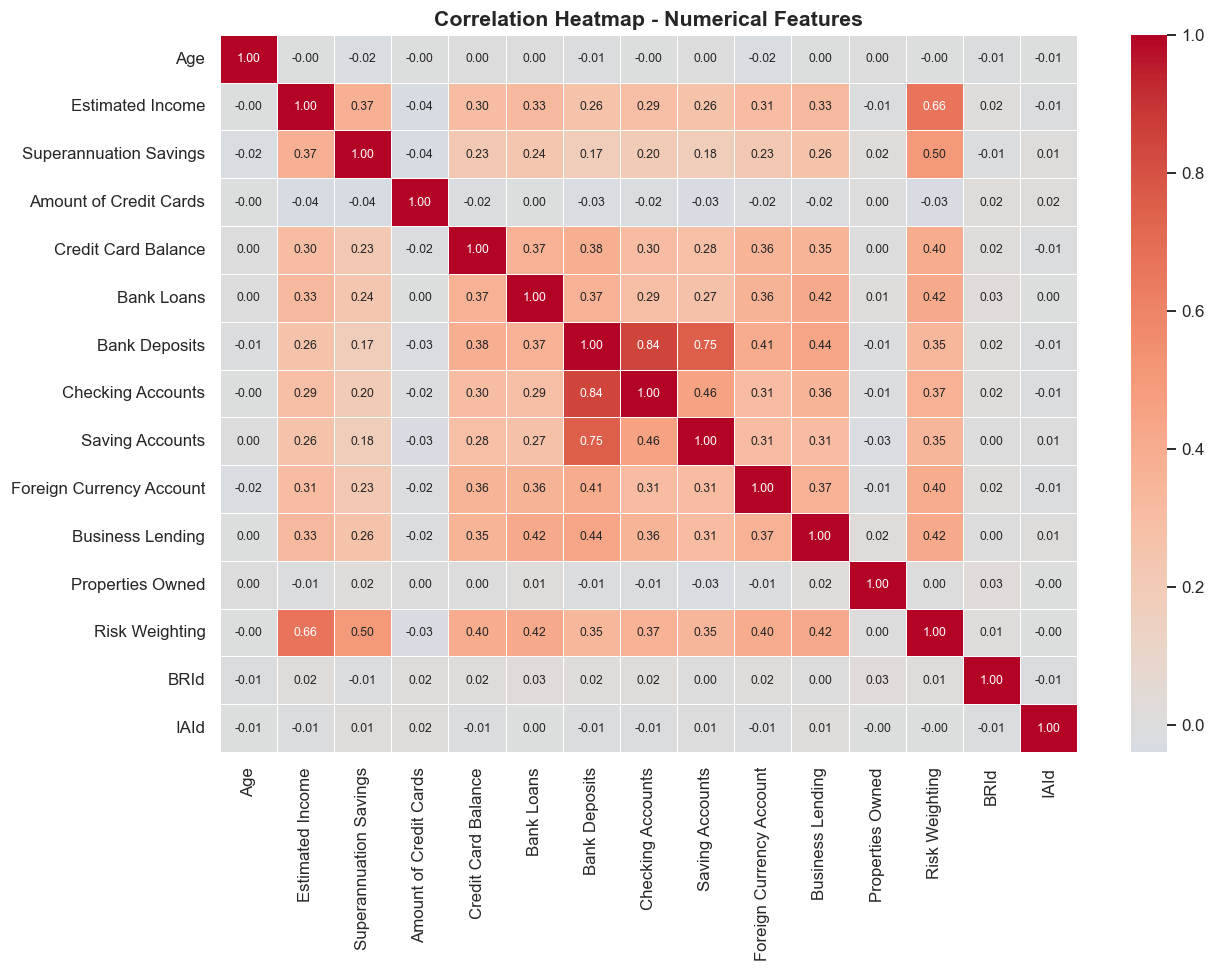

Saved: Clean_bank_dataset/07_correlation_heatmap.png


In [22]:
# correlation across the numeric columns
numerical_cols =  df.select_dtypes(include=np.number).columns.tolist()
id_like = ['Location ID', 'BRID', 'GenderId', 'IAID']  # these are just ID codes, not real numeric values
numerical_cols = [col for col in numerical_cols if col not in id_like]

corr = df[numerical_cols].corr()
fig, ax = plt.subplots(figsize=(12,9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('Correlation Heatmap - Numerical Features')
save_fig(fig, '07_correlation_heatmap')

corr_matrix = df[numerical_cols].corr()

Note: Bank Deposits and Checking Accounts are pretty strongly correlated (0.84), same with Bank Deposits and Saving Accounts (0.75) - makes sense, customers who keep more money in deposits generally keep more across all their accounts. Risk Weighting also correlates fairly well with Estimated Income (~0.66), so income does feed into the risk score even if loyalty tier doesn't track income that closely. Nothing suggests strong multicollinearity issues except that deposits/checking/savings cluster together, which is expected.

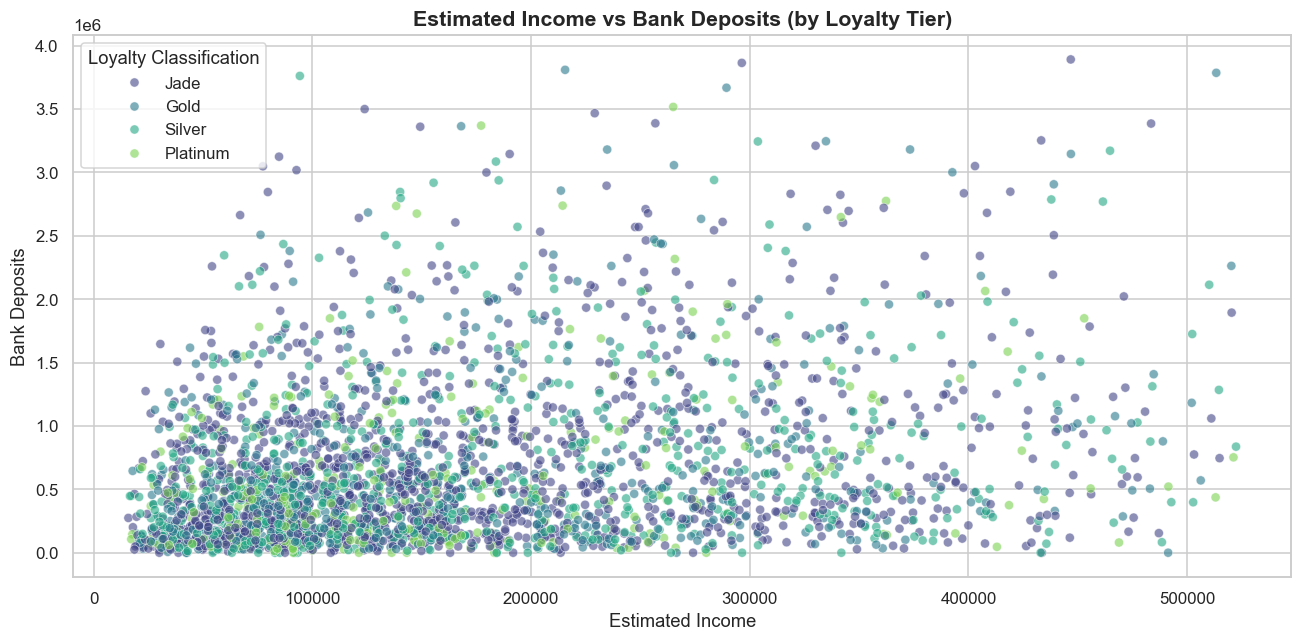

Saved: Clean_bank_dataset/08_income_vs_dposits.png


In [23]:
# income vs deposits, split by loyalty tier
fig, ax = plt.subplots(figsize=(12,6))
sns.scatterplot(data=df, x='Estimated Income', y='Bank Deposits', hue='Loyalty Classification', alpha=0.6, palette='viridis', ax=ax)
ax.set_title('Estimated Income vs Bank Deposits (by Loyalty Tier)')
save_fig(fig, '08_income_vs_dposits')

Note: no super obvious tier-based clustering in this scatter - the loyalty groups overlap quite a bit. Reinforces the earlier point that loyalty tier isn't purely a function of income/deposits.

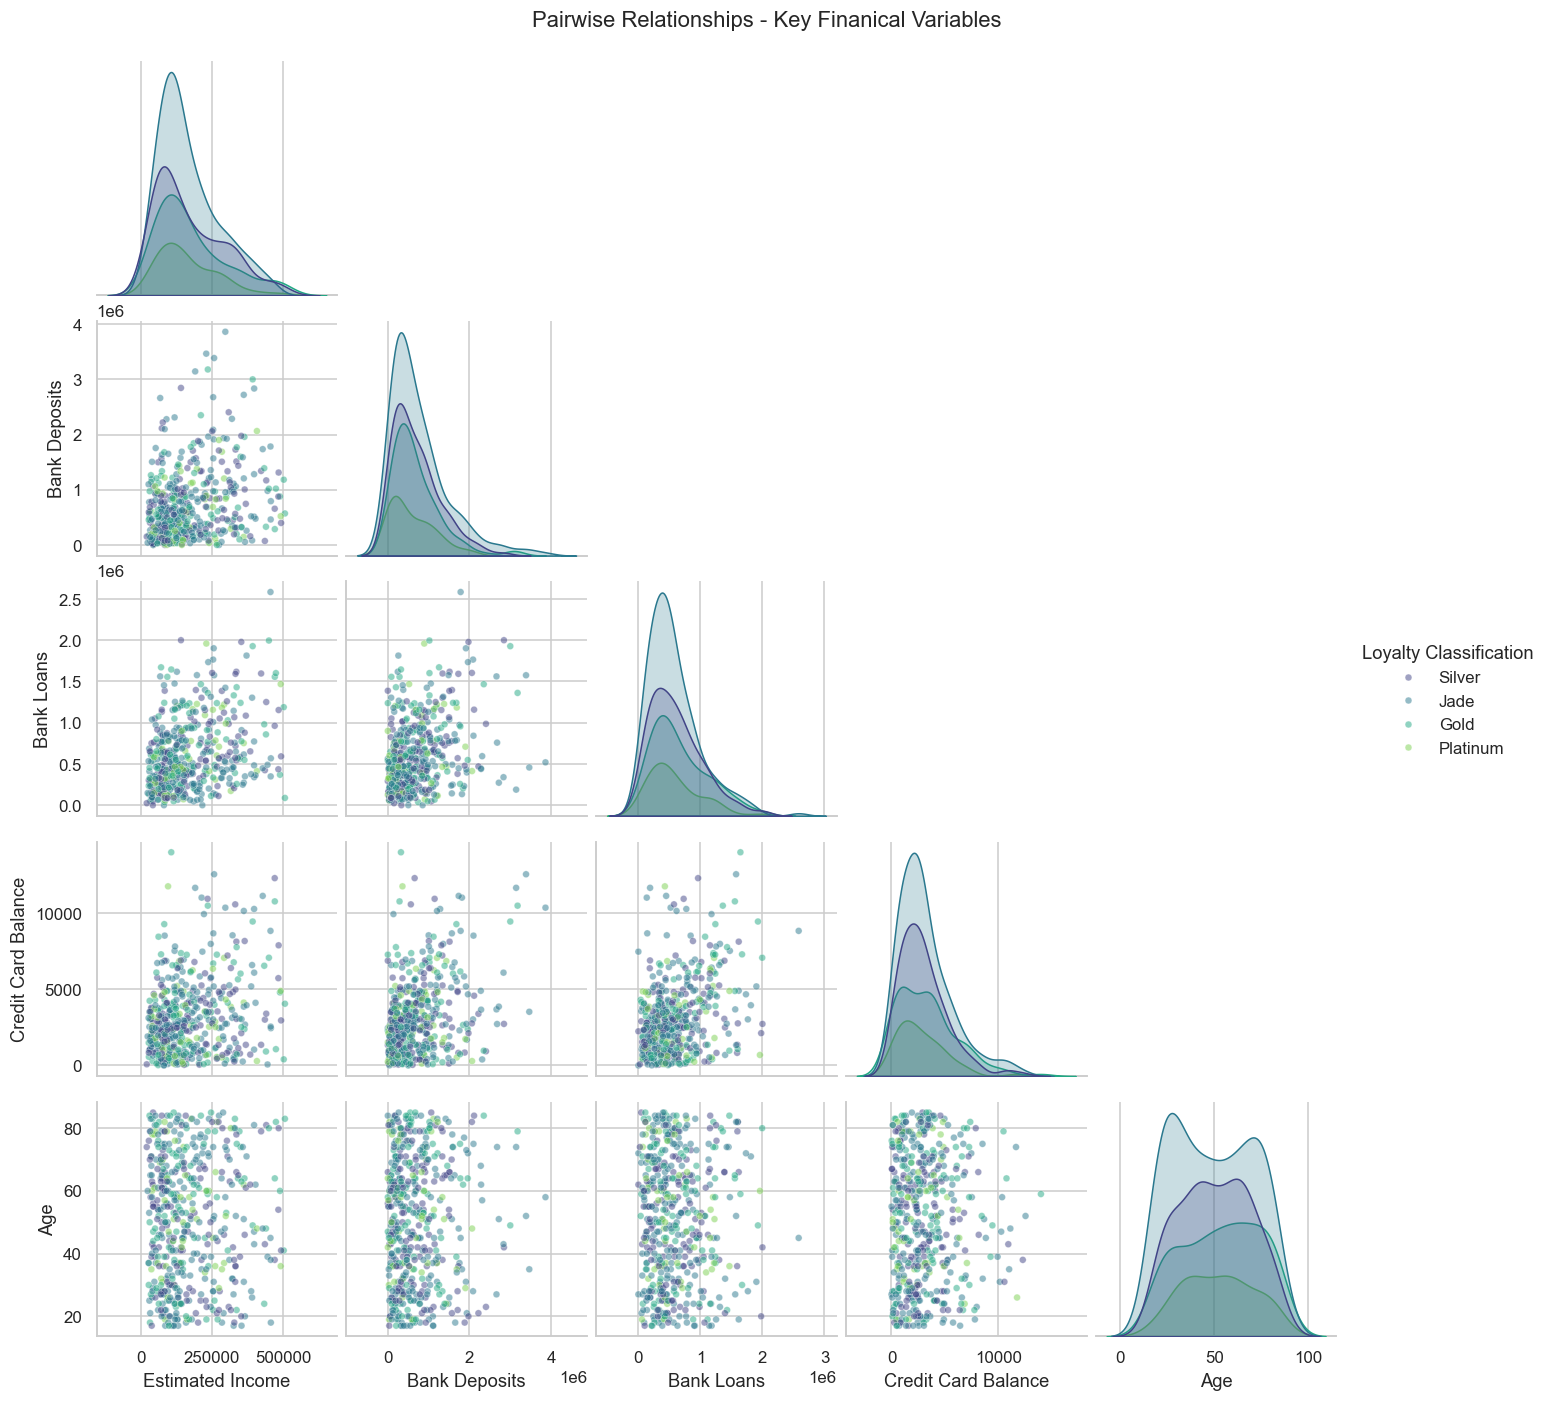

saved: Clean_bank_dataset/09_financial.png


In [24]:
# pairplot on a sample so it doesn't take forever to render
key_vars = ['Estimated Income', 'Bank Deposits', 'Bank Loans','Credit Card Balance', 'Age']
sample_df = df[key_vars + ['Loyalty Classification']].sample(n=min(500,len(df)), random_state=42)
pair = sns.pairplot(sample_df,  hue='Loyalty Classification', palette='viridis',diag_kind='kde', corner=True, plot_kws={'alpha':0.5, 's':20})
pair.fig.suptitle('Pairwise Relationships - Key Finanical Variables', y=1.02)
pair.savefig(f"{OUTPUT_DIR}/09_pairplot_financial.png", bbox_inches='tight')
plt.show()
plt.close(pair.fig)
print(f"saved: {OUTPUT_DIR}/09_financial.png")

Note: sampled 500 rows instead of all 3000 just so the pairplot renders in a reasonable time and isn't an unreadable blob of overlapping points.

## Outlier check using IQR



Outlier Summary (IQR method):
                        Lower_bound  Upper_bound  n_outliers  pct_outliers
Estimated Income         -156168.97    481365.87        26.0          0.87
Superannuation Savings    -21912.67     69891.19        19.0          0.63
Credit Card Balance        -3692.37      9451.64        85.0          2.83
Bank Loans               -639649.21   1705090.39        85.0          2.83
Bank Deposits            -903131.01   2050286.01       149.0          4.97
Business Lending         -840602.27   2400537.48        93.0          3.10


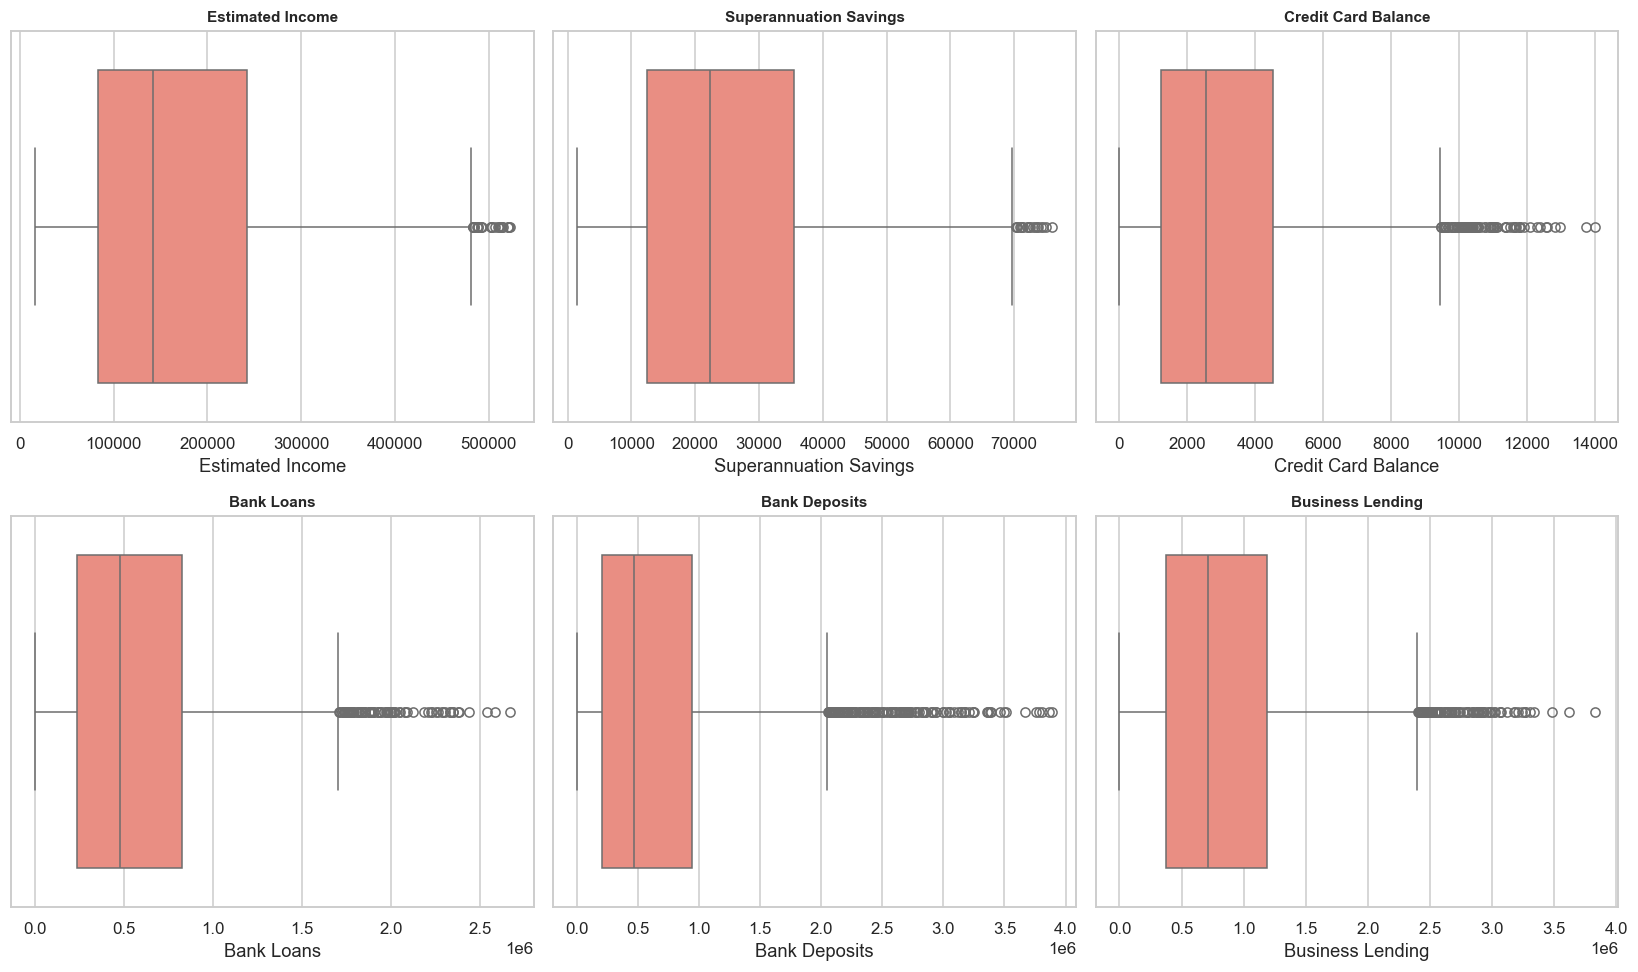

Saved: Clean_bank_dataset/10_outlier_boxplots.png


In [27]:
financial_cols_outliers = ['Estimated Income', 'Superannuation Savings', 'Credit Card Balance',
                            'Bank Loans', 'Bank Deposits', 'Business Lending']

outlier_summary = {}
for col in financial_cols_outliers:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary[col] = {
        'Lower_bound': round(lower, 2),
        'Upper_bound': round(upper, 2),
        'n_outliers': n_outliers,
        'pct_outliers': round(n_outliers / len(df) * 100, 2),
    }

# --- everything below is now OUTSIDE the for loop ---
outliers_df = pd.DataFrame(outlier_summary).T
print('\nOutlier Summary (IQR method):')
print(outliers_df)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.flatten(), financial_cols_outliers):
    sns.boxplot(x=df[col], ax=ax, color='salmon')
    ax.set_title(col, fontsize=10)
save_fig(fig, '10_outlier_boxplots')

Note: Bank Deposits has the most outliers (~5% of rows), Business Lending and Credit Card Balance/Bank Loans sit around 2.8-3%. Makes sense - a small number of high-net-worth clients or business accounts probably carry way bigger balances than the typical customer. Went with IQR here instead of z-score since these columns are skewed (not normally distributed), and IQR doesn't assume a normal distribution the way z-score does.

## PCA - just to see if customers form any natural clusters


Explained Variance (PC1, PC2): [0.423 0.139]
Total variance captured by 2 components : 56.16%


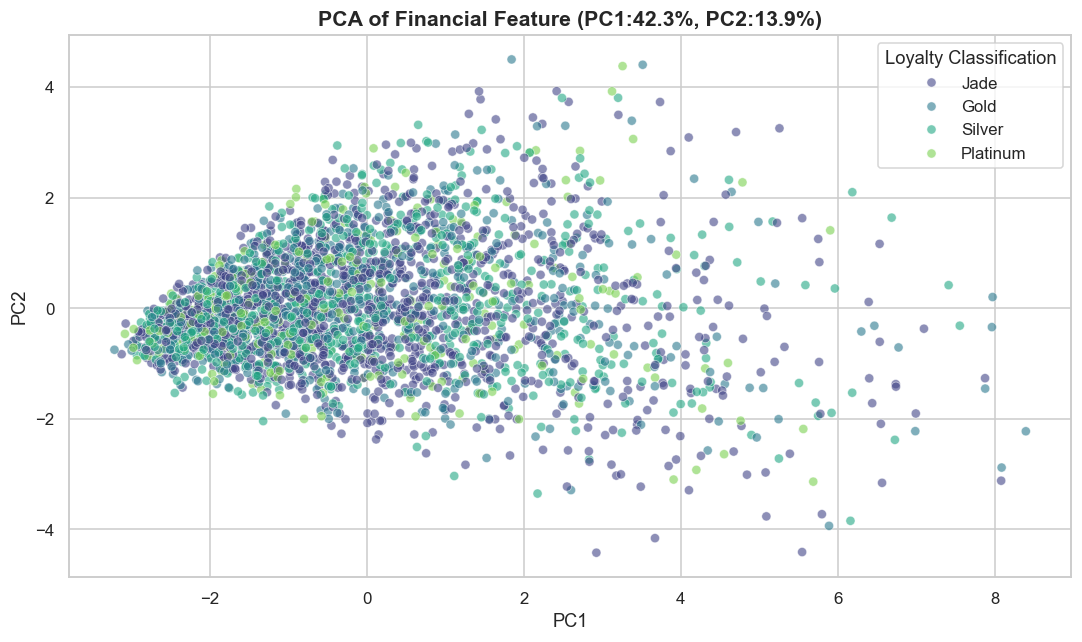

Saved: Clean_bank_dataset/11_pca_financial_profile.png


In [28]:
pca_feature = ['Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

x=df[pca_feature].values
x_scaled = StandardScaler().fit_transform(x)   # scaling first since PCA is sensitive to units/scale

pca = PCA(n_components=2, random_state=42)
Components = pca.fit_transform(x_scaled)

explained = pca.explained_variance_ratio_
print(f"\nExplained Variance (PC1, PC2): {explained.round(3)}")
print(f"Total variance captured by 2 components : {explained.sum():.2%}")

pca_df = pd.DataFrame(Components, columns=['PC1', 'PC2'])
pca_df['Loyalty Classification'] = df['Loyalty Classification'].values

fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Loyalty Classification', palette='viridis', alpha=0.6, ax=ax)
ax.set_title(f"PCA of Financial Feature (PC1:{explained[0]:.1%}, PC2:{explained[1]:.1%})")
save_fig(fig, "11_pca_financial_profile")

Note: the 2 components only capture about 56% of the total variance, so customer financial behavior here isn't really a "2D" story - there's more going on than 2 components can fully explain. Also no clean separation between loyalty tiers in this plot, which lines up with what I saw earlier - loyalty classification doesn't map neatly onto financial profile alone. If I wanted a cleaner segmentation I'd probably try 3+ components or run actual clustering (like KMeans) instead of relying on PCA visually.

In [29]:
print('\nDone - all charts saved in the clean_bank_dataset/folder')


Done - all charts saved in the clean_bank_dataset/folder


In [30]:
outliers_df.to_csv("outlier_summary.csv", index=False)
corr.to_csv("correlation_matrix.csv")
pca_df.to_csv("pca_results.csv", index=False)
df.to_csv("banking_cleaned.csv", index=False)